# Palmer Penguin Classification using KNN

This notebook develops a K-nearest neighbors (KNN) classifier to predict
the species of a penguin—Adelie, Chinstrap, or Gentoo—from physical
measurements, sex, and island of observation.

The workflow covers reproducibility, dataset preparation, exploratory
data analysis, hyperparameter selection, and evaluation on a held-out
test set.

In [1]:
%pip install -r ../requirements.txt

Note: you may need to restart the kernel to use updated packages.


## Reproducibility

A fixed random seed of **2026** is used for the train–test split and shuffled cross-validation folds.

In [2]:
import random
import numpy as np
import os
import pandas as pd
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import mlflow
import sklearn

from pandas import get_dummies
from sklearn.model_selection import train_test_split
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, RobustScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


print("MLflow:", mlflow.__version__)
print("scikit-learn:", sklearn.__version__)

seed = 2026

def set_seed(seed):
    random.seed(seed)                             # Python random module
    np.random.seed(seed)                          # NumPy
    os.environ['PYTHONHASHSEED'] = str(seed)      # Python hashing

set_seed(seed)

print("numpy     ", np.__version__)
print("pandas    ", pd.__version__)
print("seaborn   ", sns.__version__)
print("matplotlib   ", matplotlib.__version__)
print("MLflow:   ", mlflow.__version__)
print("scikit-learn:", sklearn.__version__)

MLflow: 3.16.1
scikit-learn: 1.7.2
numpy      2.3.5
pandas     2.3.3
seaborn    0.13.2
matplotlib    3.10.6
MLflow:    3.16.1
scikit-learn: 1.7.2


## Dataset Preparation

In [3]:
DATA_DIR = "../data/"
RAW_DIR = "raw/"

df = pd.read_csv(DATA_DIR + RAW_DIR + "penguins_size.csv")
df_copy = df.copy()

In [4]:
df

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,FEMALE
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,MALE
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,FEMALE


* **species (Target)** : penguin species (Chinstrap, Adélie, or Gentoo) 
* **island** : island name (Dream, Torgersen, or Biscoe) in the Palmer Archipelago (Antarctica) where sample was observed 
* **culmen_length_mm** : length of bill in mm 
* **culmen_depth_mm** : depth of bill in mm 
* **flipper_length_mm** : length of flipper in mm 
* **body_mass_g** : body mass in g 
* **sex** : sex of the penguin (male or female) 

### Preprocessing using Quantitative Techniques

#### Removing Duplicate Rows

There are no duplicate rows in the dataset.

In [5]:
print(f"The length of the dataframe before dropping duplicates is {len(df)}.")

df = df.drop_duplicates()

print(f"The length of the dataframe after dropping duplicates is {len(df)}.")

The length of the dataframe before dropping duplicates is 344.
The length of the dataframe after dropping duplicates is 344.


#### Handling Missing Values

Rows 3 and 339 are removed because all four physical measurements are missing. Their species and island values remain available, but the rows provide no observed physical measurements for this classification task. This removes 2 of 344 observations, approximately 0.58% of the dataset.

Sex labels are standardized by removing surrounding whitespace and
converting them to uppercase. Missing values and entries other than
MALE or FEMALE are assigned to an explicit Unknown category.

These observations are retained because their physical measurements
remain available. Using Unknown preserves the distinction between
unobserved sex and observed male or female labels without assuming
a penguin's sex.

In [6]:
df.isna().sum()

species               0
island                0
culmen_length_mm      2
culmen_depth_mm       2
flipper_length_mm     2
body_mass_g           2
sex                  10
dtype: int64

In [7]:
# Normalize sex labels
df["sex"] = (
    df["sex"]
    .astype("string")
    .str.strip()
    .str.upper()
)

# Replace missing or invalid entries with "Unknown"
df["sex"] = df["sex"].where(
    df["sex"].isin(["MALE", "FEMALE"]),
    "Unknown"
)

# Check the resulting categories
df["sex"].value_counts(dropna=False)

sex
MALE       168
FEMALE     165
Unknown     11
Name: count, dtype: Int64

In [8]:
# Rows with null values
df[df.isnull().any(axis=1)]

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,Unknown
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,Unknown


Rows 3 and 339 have all features with missing values, hence can be dropped from the dataset. 

In [9]:
df = df.drop(index=[3, 339])
df.reset_index(drop=True, inplace=True)

In [10]:
df

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE
...,...,...,...,...,...,...,...
337,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,FEMALE
338,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,FEMALE
339,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,MALE
340,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,FEMALE


#### Removing Outliers

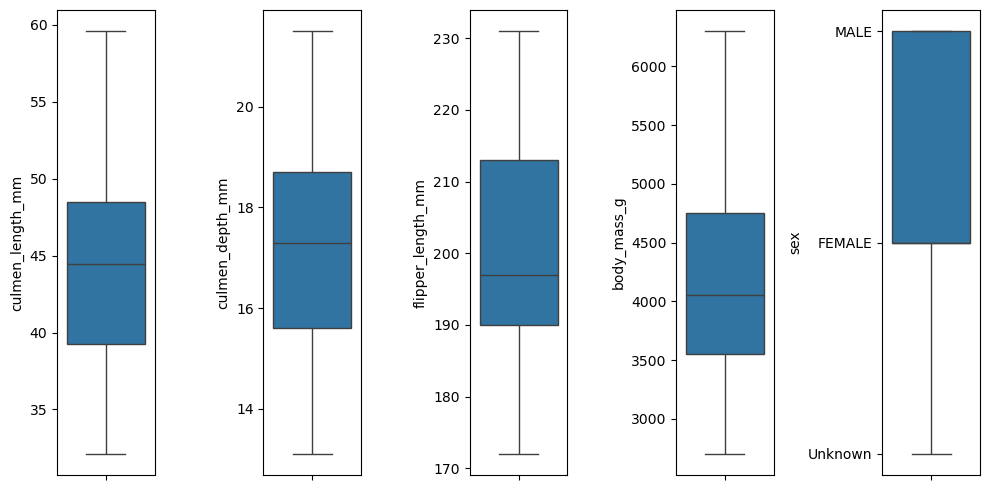

In [11]:
fig, axes = plt.subplots(1, 5, figsize=(10,5))
sns.boxplot(data=df, y="culmen_length_mm", ax=axes[0])
sns.boxplot(data=df, y="culmen_depth_mm", ax=axes[1])
sns.boxplot(data=df, y="flipper_length_mm", ax=axes[2])
sns.boxplot(data=df, y="body_mass_g", ax=axes[3])
sns.boxplot(data=df, y="sex", ax=axes[4])

plt.tight_layout()
plt.show()

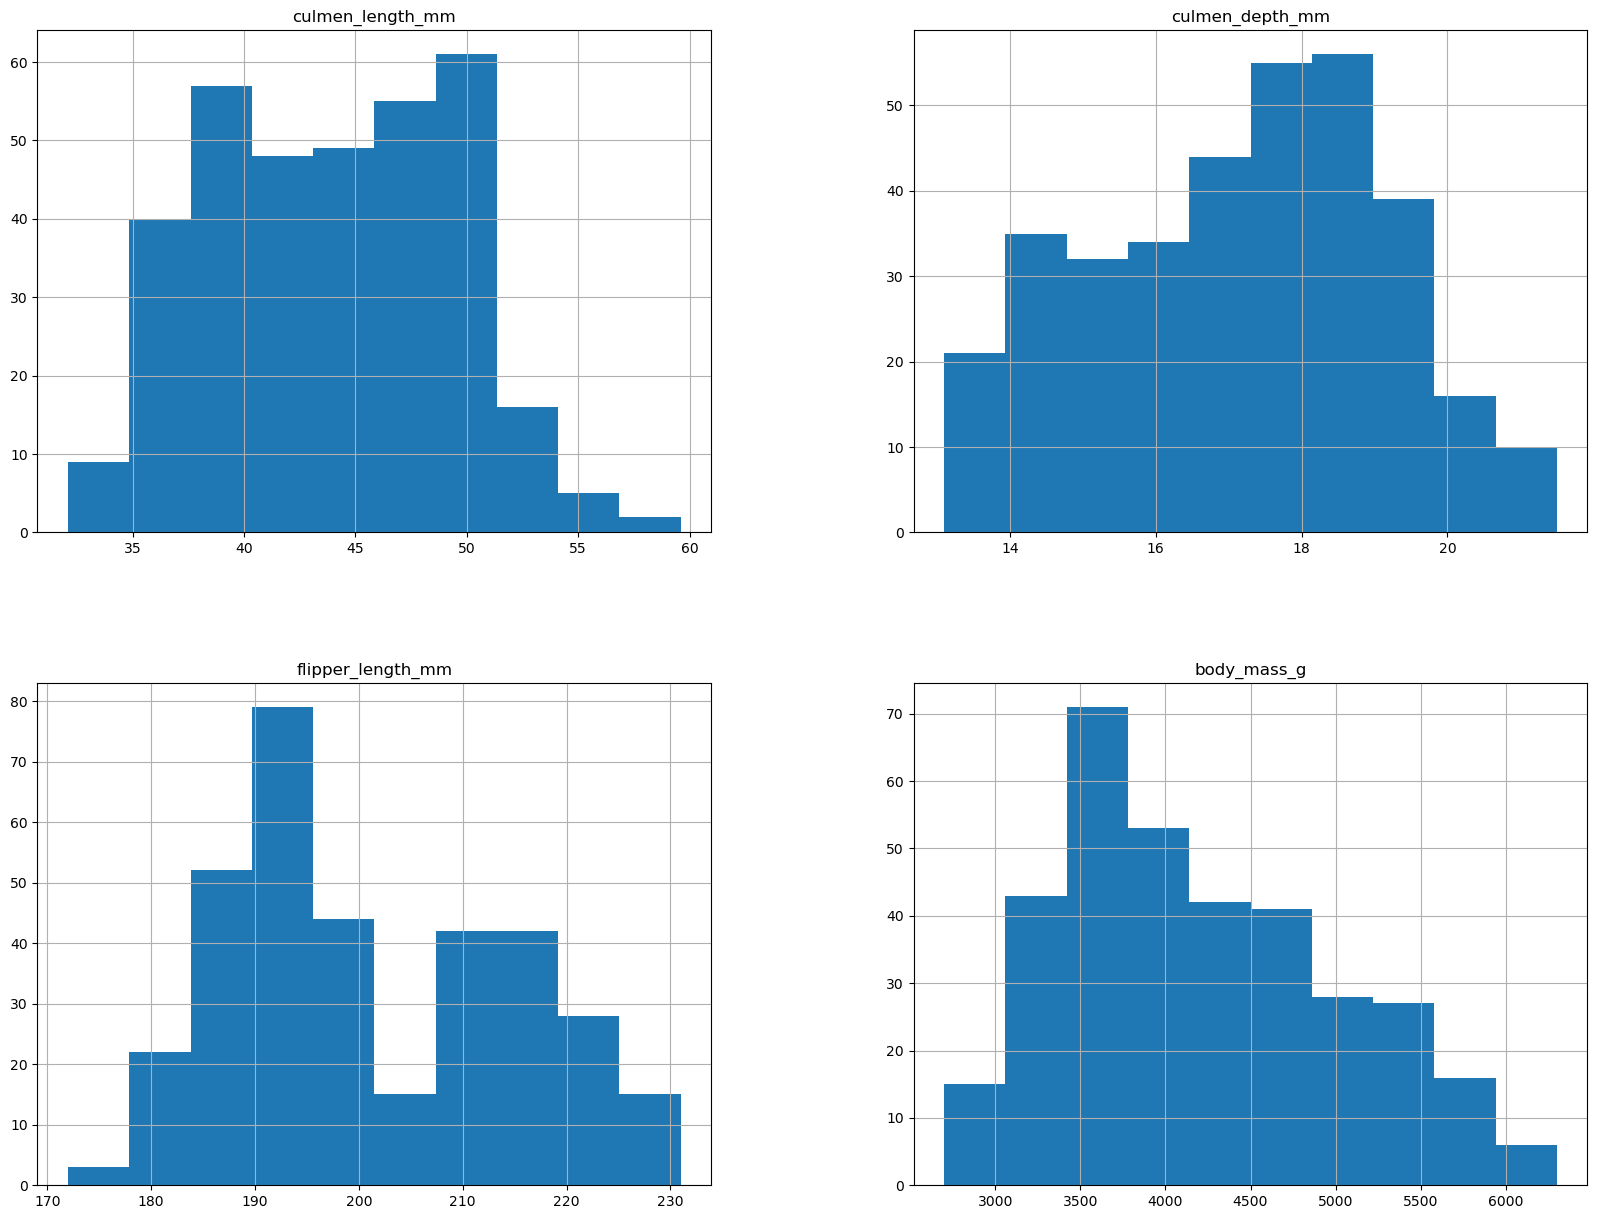

In [12]:
df.hist(figsize=(20, 15))
plt.show();

Based from the box-and-whisker plots, there are no outliers within the dataset. However, the body mass values are significantly larger in magnitude than the other physical attributes and must be handled by scaling.

#### Categorical Variables

There are two categorical variables which should be preprocessed:

* island
* sex

`one-hot-encoding` will be used to preprocess these variables.

**One-hot Encoding**

In [13]:
df = pd.get_dummies(
    df,
    columns=["sex", "island"],
    drop_first=False,
    dtype=int
)

In [14]:
df

,species,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex_FEMALE,sex_MALE,sex_Unknown,island_Biscoe,island_Dream,island_Torgersen
0,Adelie,39.1,18.7,181.0,3750.0,0,1,0,0,0,1
1,Adelie,39.5,17.4,186.0,3800.0,1,0,0,0,0,1
2,Adelie,40.3,18.0,195.0,3250.0,1,0,0,0,0,1
3,Adelie,36.7,19.3,193.0,3450.0,1,0,0,0,0,1
4,Adelie,39.3,20.6,190.0,3650.0,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...
337,Gentoo,47.2,13.7,214.0,4925.0,1,0,0,1,0,0
338,Gentoo,46.8,14.3,215.0,4850.0,1,0,0,1,0,0
339,Gentoo,50.4,15.7,222.0,5750.0,0,1,0,1,0,0
340,Gentoo,45.2,14.8,212.0,5200.0,1,0,0,1,0,0


Save the preprocessed data to `interim` folder

In [15]:
df.to_csv("../data/interim/penguins.csv", index=False)

## Exploratory Data Analysis

### Descriptive Analytics

In [16]:
# Current DataFrame
df.describe()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex_FEMALE,sex_MALE,sex_Unknown,island_Biscoe,island_Dream,island_Torgersen
count,342.000000,342.000000,342.000000,342.000000,342.000000,342.000000,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386,0.482456,0.491228,0.026316,0.488304,0.362573,0.149123
std,5.459584,1.974793,14.061714,801.954536,0.500424,0.500656,0.160307,0.500596,0.481447,0.356731
min,32.100000,13.100000,172.000000,2700.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,39.225000,15.600000,190.000000,3550.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,44.450000,17.300000,197.000000,4050.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,48.500000,18.700000,213.000000,4750.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000
max,59.600000,21.500000,231.000000,6300.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [17]:
# Species distribution
y = df.species
y.value_counts()

species
Adelie       151
Gentoo       123
Chinstrap     68
Name: count, dtype: int64

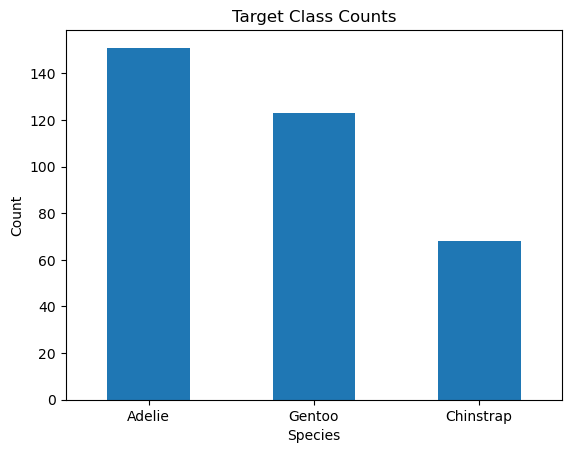

<Figure size 640x480 with 0 Axes>

In [18]:
y.value_counts().plot.bar(
    title="Target Class Counts",
    rot=0
)

plt.xlabel("Species")
plt.ylabel("Count")
plt.show()

# Saving the figure
plt.savefig("../reports/figures/001_Class_Counts.png", dpi=300)

### Bivariate Analysis

In [19]:
species_map = {
    "Adelie": 0,
    "Chinstrap": 1,
    "Gentoo": 2
}

df["species_encoded"] = df["species"].map(species_map)

In [20]:
corr = df.corr(numeric_only=True, method="pearson")

corr["species_encoded"].sort_values(ascending=False)

species_encoded      1.000000
flipper_length_mm    0.854307
body_mass_g          0.750491
culmen_length_mm     0.731369
island_Biscoe        0.608185
sex_MALE             0.011512
sex_Unknown         -0.005393
sex_FEMALE          -0.009790
island_Dream        -0.312855
island_Torgersen    -0.431225
culmen_depth_mm     -0.744076
Name: species_encoded, dtype: float64

In [21]:
df = df.drop(['sex_MALE', 'sex_FEMALE', 'sex_Unknown'], axis=1)
df.head(10)

,species,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,island_Biscoe,island_Dream,island_Torgersen,species_encoded
0,Adelie,39.1,18.7,181.0,3750.0,0,0,1,0
1,Adelie,39.5,17.4,186.0,3800.0,0,0,1,0
2,Adelie,40.3,18.0,195.0,3250.0,0,0,1,0
3,Adelie,36.7,19.3,193.0,3450.0,0,0,1,0
4,Adelie,39.3,20.6,190.0,3650.0,0,0,1,0
5,Adelie,38.9,17.8,181.0,3625.0,0,0,1,0
6,Adelie,39.2,19.6,195.0,4675.0,0,0,1,0
7,Adelie,34.1,18.1,193.0,3475.0,0,0,1,0
8,Adelie,42.0,20.2,190.0,4250.0,0,0,1,0
9,Adelie,37.8,17.1,186.0,3300.0,0,0,1,0


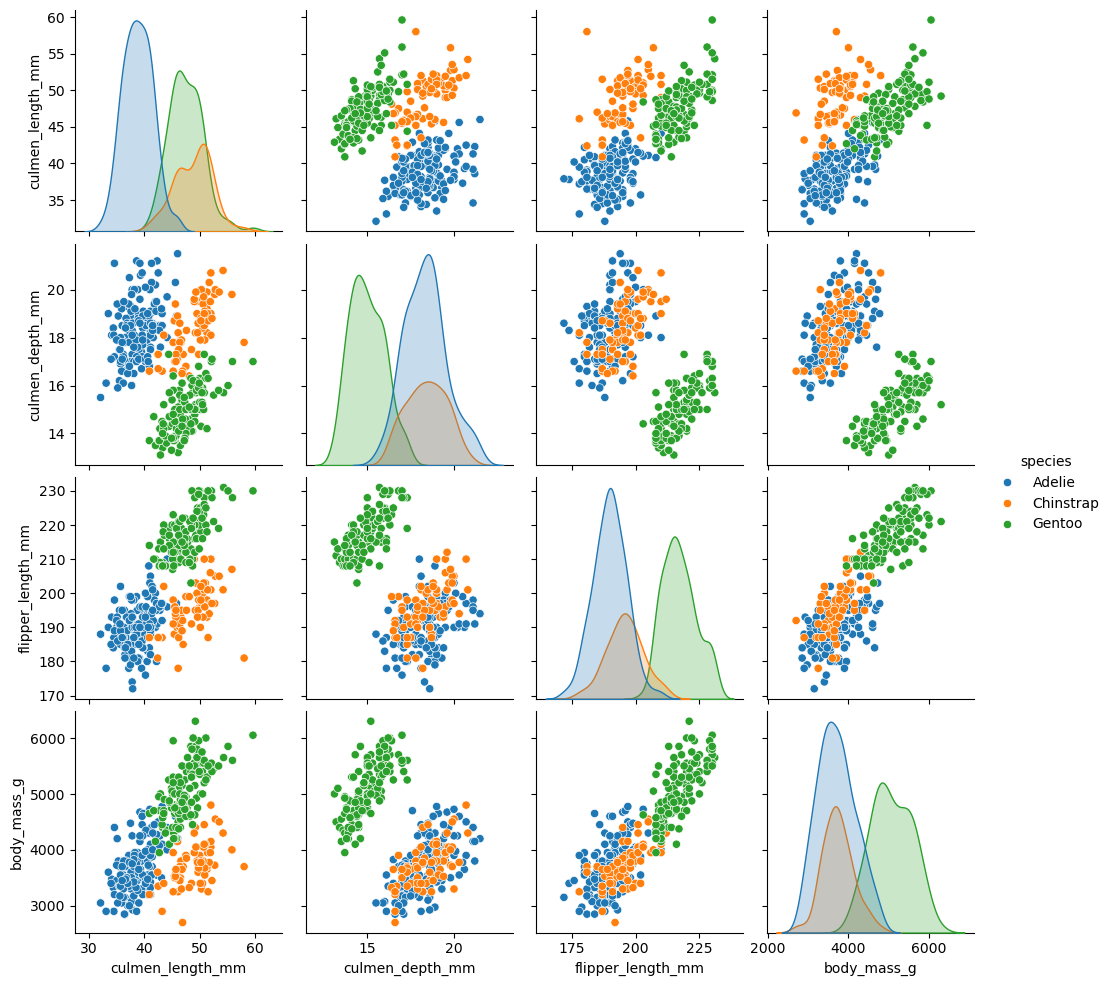

In [22]:
numeric_cols = [
    "culmen_length_mm",
    "culmen_depth_mm",
    "flipper_length_mm",
    "body_mass_g"
]

plot_df = df[numeric_cols + ["species"]].copy()

g = sns.pairplot(
    plot_df,
    hue="species",
    diag_kind="kde"
)

g.savefig(
    "../reports/figures/002_Pairplot.png",
    dpi=300
)

plt.show()

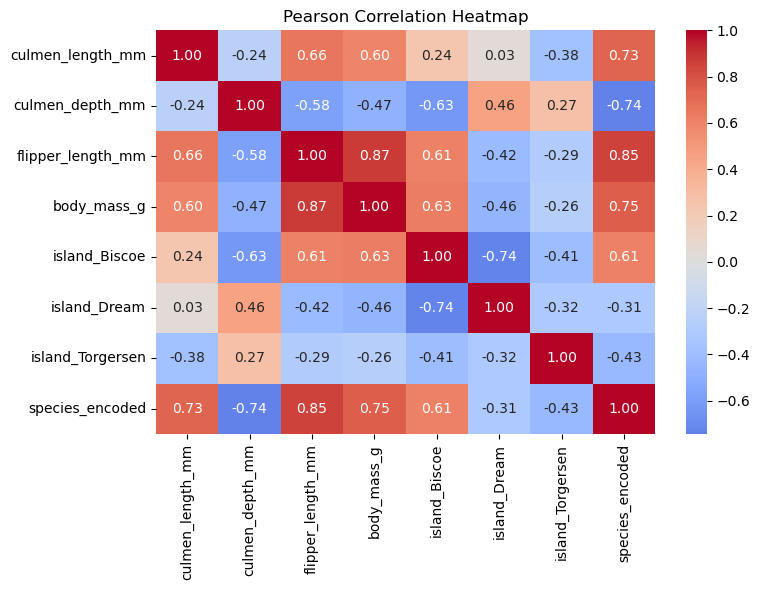

In [23]:
corr = df.corr(numeric_only=True, method="pearson")

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Pearson Correlation Heatmap")
plt.tight_layout()
# Saving the figure
plt.savefig("../reports/figures/003_Correlation_Heatmap.png", dpi=300)
plt.show();

The four physical measurements are retained because they describe
different aspects of penguin morphology. 

- **Gentoo** penguins generally have longer flippers, greater body mass,
  and shallower bills than Adelie and Chinstrap penguins. These features
  provide relatively clear separation from the other species.
- **Adelie** penguins generally have shorter bills than Chinstrap and
  Gentoo penguins.
- **Chinstrap and Adelie** overlap considerably in body mass, flipper
  length, and bill depth. Bill length helps distinguish these two species,
  particularly when considered together with bill depth.
- **Flipper length and body mass** show a positive relationship: penguins
  with longer flippers generally have greater body mass.

All four physical features are retained because they provide complementary
information for distinguishing species. 

The visible species groupings support evaluating KNN, which classifies
observations based on nearby samples. 

Island and sex are retained as potentially informative predictors.
`species_encoded` is excluded from the model inputs because it is derived
directly from the target and would cause target leakage.

# DITO JAY

In [24]:
df = df.drop(columns=["body_mass_g"])

Saving the processed data to `processed` folder

In [25]:
df.to_csv("../data/processed/penguins.csv", index=False)

## Modeling

The dataset is divided into an 80% development set and a 20% held-out test
set. Stratification preserves approximately the same species proportions
in both sets.

Hyperparameters are selected using shuffled, stratified ten-fold
cross-validation on the development set. Each configuration is evaluated
using the same folds, and scaling is fitted within each fold's training
partition.

The grid evaluates 13 neighbor counts, 2 weighting methods, 2 distance
metrics, and 2 scalers, giving 104 distinct configurations. Mean
cross-validation accuracy is the selection criterion, with its standard
deviation reported to describe variation across folds.

The held-out test set is reserved for evaluation after model selection.

In [26]:
# Train-Val Samples
print(f"The number of training + validation samples are: {np.round(len(df) * .80)}")

# Test Samples
print(f"The number of test samples are: {np.round(len(df) * .20)}")

The number of training + validation samples are: 274.0
The number of test samples are: 68.0


In [27]:
X = df.drop(["species", "species_encoded"], axis=1).copy()
y = df["species"].copy()

In [28]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y,
    train_size=int(np.round(len(df) * .80)),
    test_size=int(np.round(len(df) * .20)),
    shuffle=True,
    random_state=seed,
    stratify=y
)

In [30]:
mlflow.set_tracking_uri("sqlite:///notebooks/mlflow.db")
mlflow.set_experiment("Penguins_Experiment")

2026/10/01 17:36:25 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/10/01 17:36:25 INFO mlflow.store.db.utils: Updating database tables
2026/10/01 17:36:27 INFO mlflow.tracking.fluent: Experiment with name 'Penguins_Experiment' does not exist. Creating a new experiment.


<Experiment: artifact_location=('file:c:/Users/Jan Ver Dominic Edra/OneDrive/Documents/MSDS2027/Term '
 '2/ML1/penguins_classification/notebooks/mlruns/1'), creation_time=1790847387563, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1790847387563, lifecycle_stage='active', name='Penguins_Experiment', tags={}, trace_location=None, workspace='default'>

In [31]:
# Proportion Chance Criterion (PCC)
pcc = 1.25 * ((y.value_counts() / len(y)) ** 2).sum().item()
pcc

0.4547766834239595

Hence, the accuracy must be greater than 0.45 to say that the model is more accurate than random chance alone.

In [32]:
n_runs = 0
n_splits = 10
search_run_ids = []

# Hyperparameter grid: 13 × 2 × 2 × 2 = 104 combinations
grid = {
    "n_neighbors": [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "cosine"],
    "scalers": {
        "minmax": MinMaxScaler(),
        "robust": RobustScaler()
    }
}

total_combinations = (
    len(grid["n_neighbors"])
    * len(grid["weights"])
    * len(grid["metric"])
    * len(grid["scalers"])
)

# Use the same folds for every configuration
kf = StratifiedKFold(
    n_splits=n_splits,
    shuffle=True,
    random_state=seed
)

for n_neighbors in grid["n_neighbors"]:
    for weights in grid["weights"]:
        for metric in grid["metric"]:
            for scaler_name, scaler in grid["scalers"].items():

                with mlflow.start_run(run_name=f"{n_runs}_KNN") as run:
                    # Track only runs from this execution
                    search_run_ids.append(run.info.run_id)

                    print(
                        f"Running {n_runs + 1} "
                        f"out of {total_combinations} runs"
                    )

                    knn_params = {
                        "n_neighbors": n_neighbors,
                        "weights": weights,
                        "metric": metric
                    }

                    mlflow.log_params({
                        **knn_params,
                        "scaler": scaler_name
                    })

                    accuracy_list = []
                    precision_list = []
                    recall_list = []
                    f1_score_list = []

                    for fold, (train_index, val_index) in enumerate(
                        kf.split(X_trainval, y_trainval)
                    ):
                        knn_pipeline = Pipeline([
                            ("scaler", clone(scaler)),
                            ("cls", KNeighborsClassifier(**knn_params))
                        ])

                        # Train on this fold's training partition
                        knn_pipeline.fit(
                            X_trainval.iloc[train_index],
                            y_trainval.iloc[train_index]
                        )

                        # Predict on this fold's validation partition
                        y_pred = knn_pipeline.predict(
                            X_trainval.iloc[val_index]
                        )
                        y_true = y_trainval.iloc[val_index]

                        accuracy = accuracy_score(y_true, y_pred)

                        precision = precision_score(
                            y_true,
                            y_pred,
                            average="macro",
                            zero_division=0
                        )

                        recall = recall_score(
                            y_true,
                            y_pred,
                            average="macro",
                            zero_division=0
                        )

                        f1 = f1_score(
                            y_true,
                            y_pred,
                            average="macro",
                            zero_division=0
                        )

                        # Log fold metrics
                        mlflow.log_metrics(
                            {
                                "accuracy": accuracy,
                                "precision_macro": precision,
                                "recall_macro": recall,
                                "f1_macro": f1
                            },
                            step=fold
                        )

                        accuracy_list.append(accuracy)
                        precision_list.append(precision)
                        recall_list.append(recall)
                        f1_score_list.append(f1)

                    # Log overall cross-validation metrics
                    overall_metrics = {
                        "mean_accuracy":
                            np.mean(accuracy_list).item(),
                        "mean_precision_macro":
                            np.mean(precision_list).item(),
                        "mean_recall_macro":
                            np.mean(recall_list).item(),
                        "mean_f1_macro":
                            np.mean(f1_score_list).item(),
                        "std_accuracy":
                            np.std(accuracy_list, ddof=1).item(),
                        "std_precision_macro":
                            np.std(precision_list, ddof=1).item(),
                        "std_recall_macro":
                            np.std(recall_list, ddof=1).item(),
                        "std_f1_macro":
                            np.std(f1_score_list, ddof=1).item()
                    }

                    mlflow.log_metrics(overall_metrics)
                    n_runs += 1

Running 1 out of 104 runs
Running 2 out of 104 runs
Running 3 out of 104 runs
Running 4 out of 104 runs
Running 5 out of 104 runs
Running 6 out of 104 runs
Running 7 out of 104 runs
Running 8 out of 104 runs
Running 9 out of 104 runs
Running 10 out of 104 runs
Running 11 out of 104 runs
Running 12 out of 104 runs
Running 13 out of 104 runs
Running 14 out of 104 runs
Running 15 out of 104 runs
Running 16 out of 104 runs
Running 17 out of 104 runs
Running 18 out of 104 runs
Running 19 out of 104 runs
Running 20 out of 104 runs
Running 21 out of 104 runs
Running 22 out of 104 runs
Running 23 out of 104 runs
Running 24 out of 104 runs
Running 25 out of 104 runs
Running 26 out of 104 runs
Running 27 out of 104 runs
Running 28 out of 104 runs
Running 29 out of 104 runs
Running 30 out of 104 runs
Running 31 out of 104 runs
Running 32 out of 104 runs
Running 33 out of 104 runs
Running 34 out of 104 runs
Running 35 out of 104 runs
Running 36 out of 104 runs
Running 37 out of 104 runs
Running 38

In [33]:
runs = mlflow.search_runs()

# Keep only runs from the current hyperparameter search
current_runs = runs[
    runs["run_id"].isin(search_run_ids)
    & runs["status"].eq("FINISHED")
].copy()

# Rank by highest mean accuracy, then lowest standard deviation
results = current_runs[
    [
        "tags.mlflow.runName",
        "params.n_neighbors",
        "params.weights",
        "params.metric",
        "params.scaler",
        "metrics.mean_accuracy",
        "metrics.std_accuracy"
    ]
].rename(
    columns={"tags.mlflow.runName": "run_name"}
).sort_values(
    ["metrics.mean_accuracy", "metrics.std_accuracy"],
    ascending=[False, True]
)

display(results.head(10))

,run_name,params.n_neighbors,params.weights,params.metric,params.scaler,metrics.mean_accuracy,metrics.std_accuracy
77,26_KNN,7,uniform,cosine,minmax,0.996296,0.011712
1,102_KNN,25,distance,cosine,minmax,0.992725,0.015340
2,101_KNN,25,distance,euclidean,robust,0.992725,0.015340
5,98_KNN,25,uniform,cosine,minmax,0.992725,0.015340
6,97_KNN,25,uniform,euclidean,robust,0.992725,0.015340
9,94_KNN,23,distance,cosine,minmax,0.992725,0.015340
13,90_KNN,23,uniform,cosine,minmax,0.992725,0.015340
17,86_KNN,21,distance,cosine,minmax,0.992725,0.015340
18,85_KNN,21,distance,euclidean,robust,0.992725,0.015340
21,82_KNN,21,uniform,cosine,minmax,0.992725,0.015340


## Evaluation

**Accuracy** is the primary metric because the objective is to maximize the
overall proportion of correctly classified penguins. Macro precision,
recall, and F1 provide complementary information by giving each species
equal weight despite unequal class frequencies.

The selected configuration is fitted on the full training-validation set and
evaluated on a separate test set. The primary test metric is saved in
MLflow as `test_accuracy`.

Based on the MLFlow experiment, a few model pipelines exhibited 99.63% mean accuracy with 0.0117 standard deviation accross all cross validation folds. The selected configuration uses 25 neighbors, distance weighting, cosine
distance, and robust scaler. Its cross-validation performance is reported
from the current hyperparameter search.

* **metric** = cosine
* **n_neighbors** = 23
* **scaler** = minmax
* **weights** = uniform 

The selected pipeline is refitted on all 274 development observations
and evaluated on the 68 held-out test observations. The test set is used
only after hyperparameter selection.


In [34]:
with mlflow.start_run(run_name=f"Test_KNN"):
    params = {
        "metric": "cosine",
        "n_neighbors": 23,
        "weights": "uniform",
        "scaler": "minmax"
    }

    mlflow.log_params(params)

    del params["scaler"]
    
    knn_pipeline = Pipeline(
        [("scaler", RobustScaler()),
         ("cls",  KNeighborsClassifier(**params))]
    )
    
    knn_pipeline.fit(X_trainval, y_trainval)

    y_pred = knn_pipeline.predict(X_test)
    accuracy = accuracy_score(y_pred, y_test)
    print(f"Test accuracy: {accuracy:.4f}")

    mlflow.log_metric("test_accuracy", accuracy)

Test accuracy: 0.9853


The selected model achieved a test accuracy of **98.53%**
on **68 test observations**.This means that the model was able to correctly claasify all penguins to its respective species.

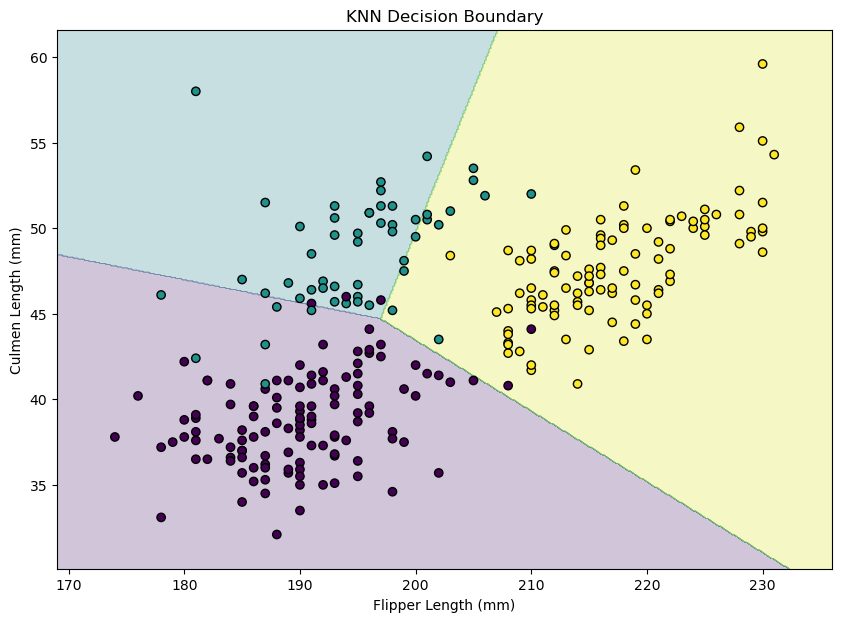

In [35]:
# Decision Boundary

# Prepare data
X = X_trainval.values
y = y_trainval

knn_pipeline.fit(X, y)

# Get feature positions
flipper_idx = X_trainval.columns.get_loc("flipper_length_mm")
culmen_idx = X_trainval.columns.get_loc("culmen_length_mm")

# Create grid limits
x_min = X[:, flipper_idx].min() - 5
x_max = X[:, flipper_idx].max() + 5

y_min = X[:, culmen_idx].min() - 2
y_max = X[:, culmen_idx].max() + 2

# Create grid
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

# Hold all other features at their median values
X_grid = np.tile(
    np.median(X, axis=0),
    (xx.size, 1)
)

# Vary only flipper length and culmen length
X_grid[:, flipper_idx] = xx.ravel()
X_grid[:, culmen_idx] = yy.ravel()

# Predict every point in the grid
Z = knn_pipeline.predict(X_grid)

# Encode species for plotting
species_to_num = {
    "Adelie": 0,
    "Chinstrap": 1,
    "Gentoo": 2
}

Z_numeric = np.array([species_to_num[label] for label in Z])
Z_numeric = Z_numeric.reshape(xx.shape)

y_numeric = y.map(species_to_num)

plt.figure(figsize=(10, 7))

# Decision regions
plt.contourf(
    xx,
    yy,
    Z_numeric,
    alpha=0.25
)

# Observations
plt.scatter(
    X[:, flipper_idx],
    X[:, culmen_idx],
    c=y_numeric,
    edgecolor="k"
)

plt.xlabel("Flipper Length (mm)")
plt.ylabel("Culmen Length (mm)")
plt.title("KNN Decision Boundary")

plt.savefig("../reports/figures/004_KNN_Decision_Boundary.png", dpi=300)

plt.show()